# Optimization
This notebooks aims to find optimal parameter for the simulation.

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.fire_spreading_model import FireSpreadingAdvanced, Parameters
from src.data_preprocessing import SentinelClient
from src.helper_functions import calculate_rect_dimensions

## Training Data
We use a real fire as training data. Ideally, this real fire was extinguished without outside intervention as our model doesn't include any kind of firefighting yet.

The Santa Rosa Island Fire is currently active with minimal intervention as of 19th may (https://www.fire.ca.gov/incidents/2026/5/15/santa-rosa-island-fire)

Another candidate from 2025: https://www.fire.ca.gov/incidents/2025/7/1/green-fire/
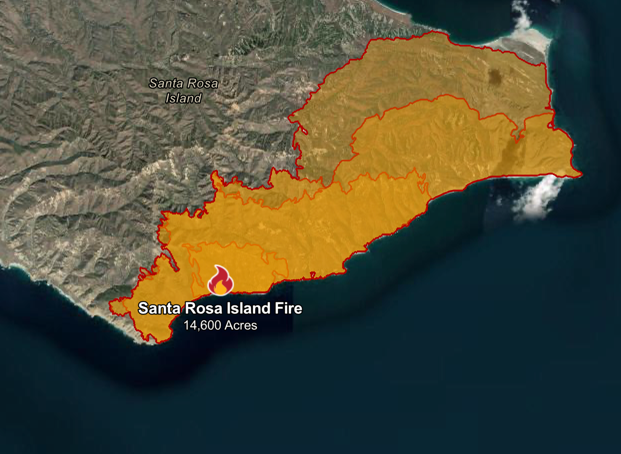
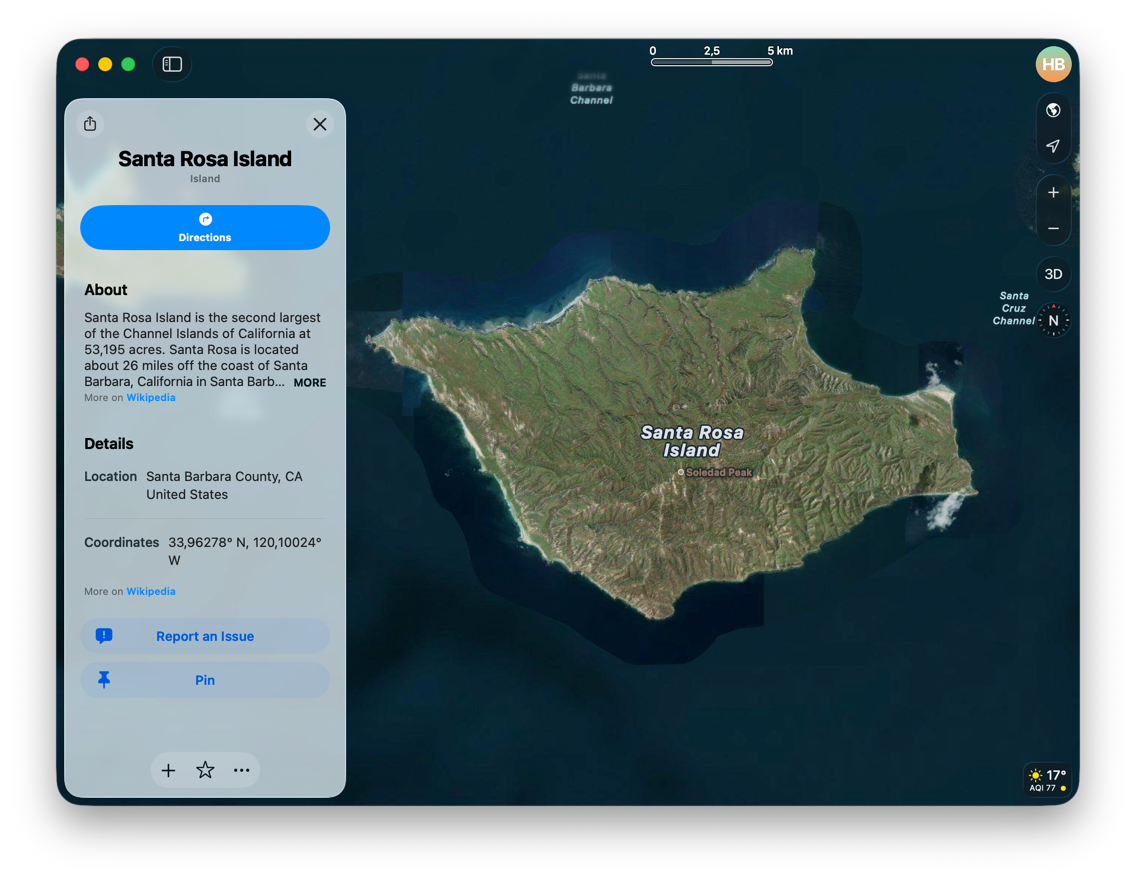

In [43]:
# Santa Rosa
start_date = ("2026-04-20", "2026-04-24")  # actual start date: 2026-05-15 4:19 pm
end_date = ("2026-05-19", "2026-05-24")  # actual "end" date: 2026-05-19

lat_range = (33.859, 34.072)
lon_range = (-120.283, -119.945)

width_km, height_km = calculate_rect_dimensions(lat_range, lon_range)
px_dimemnsion_km = 0.015

width_px = round(width_km / px_dimemnsion_km)
height_px = round(height_km / px_dimemnsion_km)

sc = SentinelClient()
photo_true_colour_before = sc.get_photo(np.min(lon_range), np.min(lat_range),
                                        np.max(lon_range), np.max(lat_range),
                                        start_date[0], start_date[1], width_px, height_px)

photo_true_colour_after = sc.get_photo(np.min(lon_range), np.min(lat_range),
                                       np.max(lon_range), np.max(lat_range),
                                       end_date[0], end_date[1], width_px, height_px)

Width: 31.206km, Height: 23.711km, Area: 739.934sq km


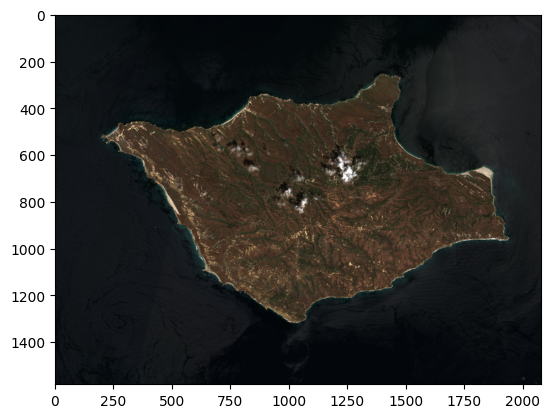

In [44]:
plt.imshow(photo_true_colour_before)
print(f"Width: {width_km:.3f}km, Height: {height_km:.3f}km, Area: {width_km*height_km:.3f}sq km")

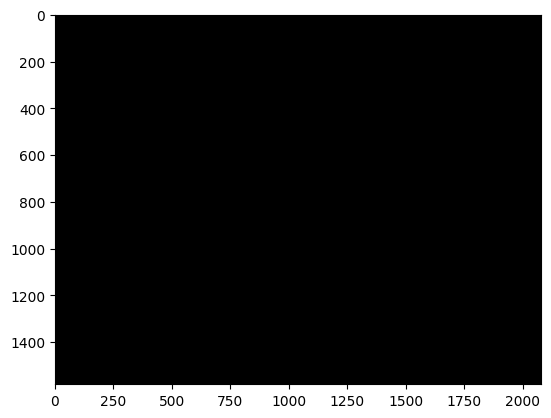

In [45]:
plt.imshow(photo_true_colour_after)

### Green Fire

In [61]:
# Green Fire
start_date = ("2025-06-20", "2025-06-25")  # actual start date: 2025-07-01 4:19 pm
end_date = ("2025-07-18", "2025-07-20")  # actual end date: containment started with 2025-7-19

lat_range = (40.720, 40.910)
lon_range = (-122.009, -122.179)

width_km, height_km = calculate_rect_dimensions(lat_range, lon_range)
px_dimemnsion_km = 0.020

width_px = round(width_km / px_dimemnsion_km)
height_px = round(height_km / px_dimemnsion_km)

sc = SentinelClient()
photo_true_colour_before = sc.get_photo(np.min(lon_range), np.min(lat_range),
                                        np.max(lon_range), np.max(lat_range),
                                        start_date[0], start_date[1], width_px, height_px)

photo_true_colour_after = sc.get_photo(np.min(lon_range), np.min(lat_range),
                                       np.max(lon_range), np.max(lat_range),
                                       end_date[0], end_date[1], width_px, height_px)

Width: 14.322km, Height: 21.151km, Area: 302.931sq km


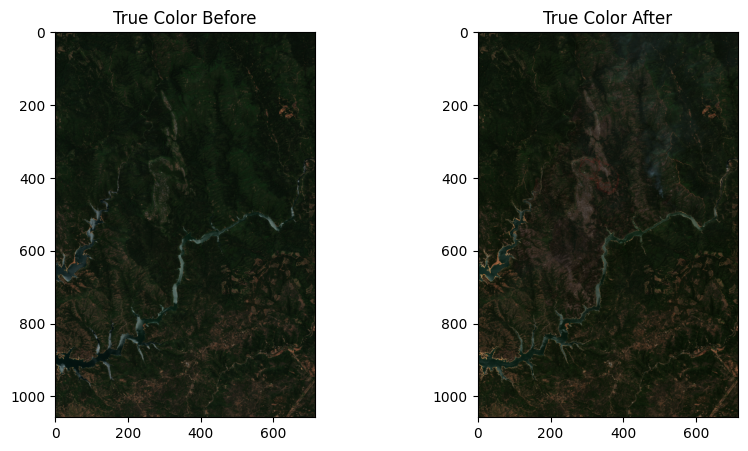

In [62]:
print(f"Width: {width_km:.3f}km, Height: {height_km:.3f}km, Area: {width_km*height_km:.3f}sq km")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(photo_true_colour_before)
ax[0].set_title("True Color Before")
ax[1].imshow(photo_true_colour_after)
ax[1].set_title("True Color After")
plt.show()

Simulation time (T): 672 time steps


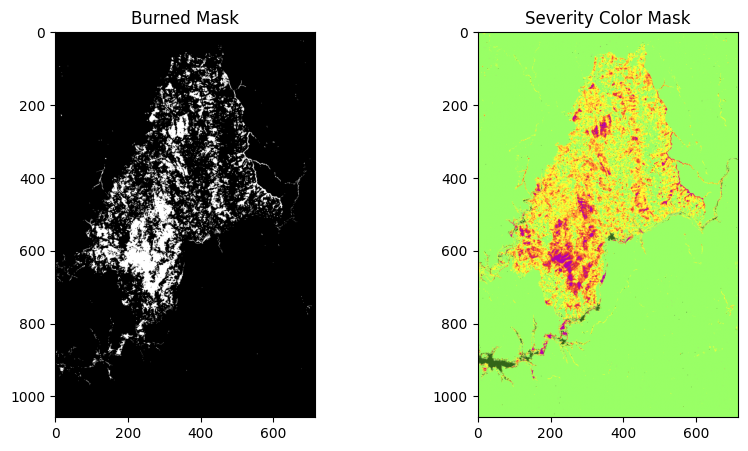

In [63]:
# Retrieve data
data_before = sc.get_data(np.min(lon_range), np.min(lat_range), np.max(lon_range), np.max(lat_range),
                          start_date[0], start_date[1], width_px, height_px)
data_after = sc.get_data(np.min(lon_range), np.min(lat_range), np.max(lon_range), np.max(lat_range),
                         end_date[0], end_date[1], width_px, height_px)

fuel_before, water_before, moisture_before, burnt_before = data_before
fuel_after_real_data, water_after_real_data, moisture_after_real_data, burnt_after_real_data = data_after

topo = sc.get_topo(np.min(lon_range), np.min(lat_range), np.max(lon_range), np.max(lat_range),
                   width_px, height_px)

#dNBR = (NBR_before - NBR_after)
dnbr = (burnt_before - burnt_after_real_data)

# Create the Target Burn Mask based on NBR and water levels
# white pixels indicate areas that were burned, while black pixels indicate unburned areas
target_mask = (dnbr > 0.1)

# Calculate simulation time in hours
T = sc.get_simulation_time(start_date[0], end_date[0]) * 24
print(f"Simulation time (T): {T} time steps")

# severity mask based on dNBR
severity_color_mask, burned_mask = sc.get_severity_mask(dnbr)

# visualize the burned_mask and severity_color_mask
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(burned_mask, cmap='gray')
plt.title("Burned Mask")
plt.subplot(1,2,2)
plt.imshow(severity_color_mask)
plt.title("Severity Color Mask")
plt.show()

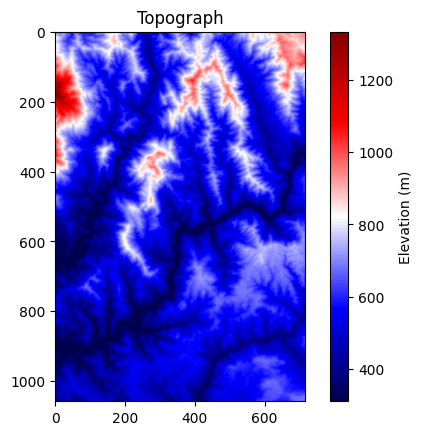

In [64]:
plt.imshow(topo, cmap="seismic")
plt.colorbar(label="Elevation (m)")
plt.title("Topograph")
plt.show()

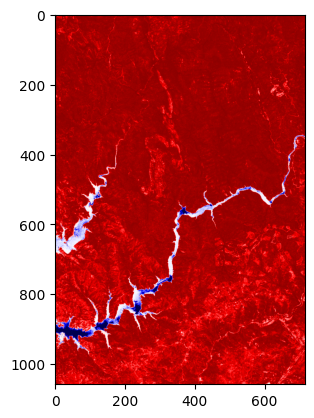

In [65]:
plt.imshow(fuel_before, cmap="seismic")

In [66]:
# store masks for faster access
px = int(px_dimemnsion_km * 1000)
np.savetxt(f"../data/green_fire/burned_px={px}m.csv", burned_mask, delimiter=";")
np.savetxt(f"../data/green_fire/burnedbefore_px={px}m.csv", burnt_before, delimiter=";")
np.savetxt(f"../data/green_fire/burnedafter_px={px}m.csv", burnt_after_real_data, delimiter=";")
#np.savetxt(f"../data/green_fire/severity_px={px}m.csv", severity_color_mask, delimiter=";")
np.savetxt(f"../data/green_fire/topo_px={px}m.csv", topo, delimiter=";")
np.savetxt(f"../data/green_fire/moisturebefore_px={px}m.csv", moisture_before, delimiter=";")
np.savetxt(f"../data/green_fire/moistureafter_px={px}m.csv", moisture_after_real_data, delimiter=";")
np.savetxt(f"../data/green_fire/waterbefore_px={px}m.csv", water_before, delimiter=";")
np.savetxt(f"../data/green_fire/waterafter_px={px}m.csv", water_after_real_data, delimiter=";")
np.savetxt(f"../data/green_fire/fuelbefore_px={px}m.csv", fuel_before, delimiter=";")
np.savetxt(f"../data/green_fire/fuelafter_px={px}m.csv", fuel_after_real_data, delimiter=";")
np.savetxt(f"../data/green_fire/dnbr_px={px}m.csv", dnbr, delimiter=";")